# Taller Tercer Corte — Máquinas Térmicas

## Contexto: Intercooler en un Motor Wankel 6T con Turboalimentación

En un motor de combustión interna, la turboalimentación permite aumentar la potencia de salida al comprimir el aire de admisión, incrementando así la masa de oxígeno disponible en la cámara de combustión. Sin embargo, el proceso de compresión eleva la temperatura del aire, lo que genera dos efectos negativos:
- Disminuye la densidad del aire, contrarrestando parcialmente el efecto del turbo.
- Aumenta la temperatura de combustión, lo que puede promover la formación de NOx y el riesgo de detonación.

Para tratar de mitigar estos efectos se emplea un intercooler (enfriador de aire), es un intercambiador de calor que reduce la temperatura del aire comprimido antes de ingresar al motor, aumentando su densidad y mejorando la eficiencia volumétrica. En un motor Wankel 6T, cuyo ciclo ya presenta desafíos térmicos por la segunda combustión, en caso de añadir turboalimentación al proceso, el uso de un intercooler adquiere una gran relevancia.

**Objetivo de este análisis:**

Evaluar el comportamiento de un intercooler aire-aire aplicado a un motor Wankel 6T turboalimentado, mediante el estudio de las siguientes variables:

- **Efectividad del intercambiador ($\varepsilon$):** En función de diferentes configuraciones geométricas y flujos másicos.
- **Número de unidades de transferencia (NTU):** Y su relación con la efectividad.
- **Coeficiente de convección:** Para diferentes flujos de aire caliente (lado de carga) y aire frío (lado de enfriamiento).
- **Variación de la temperatura de admisión:** Al motor ($T_{out}$) para diferentes relaciones de capacidad calorífica ($C_r$).
- **Comparación termodinámica:** Entre un ciclo con turbo + intercooler y un ciclo con turbo solamente, mediante diagramas P-V, evaluando el trabajo de compresión requerido.

Identificar cuantitativamente la reducción en el trabajo de compresión (ahorro energético) al enfriar el aire de admisión, y determinar la configuración óptima del intercooler para maximizar la densidad del aire de entrada sin aumentar excesivamente la complejidad del sistema.

## Intercooler Aire-Aire: Modelo 0D Transitorio acoplado al Motor Wankel 6T

**Dispositivo:** Intercooler de flujo cruzado (aire caliente → aire frío ambiente)

**Posición:** Salida turbocompresor → **Intercooler** → Admisión Wankel 6T

**Objetivo:** Modelar la transferencia de calor en régimen transitorio, calcular la efectividad del intercambiador y cuantificar la **ganancia de potencia/trabajo neto** en el ciclo Wankel 6T.

**Metodología:** Modelo 0D Transitorio, siguiendo la misma estructura de la *Lección 14 — Modelación del Condensador de Carcasa y Tubos*:

| Contenido |
|---|
| Condiciones de operación, geometría y propiedades |
| Números adimensionales (Re, Pr, Nu) |
| Coeficientes $h$, conducción y convección |
| EDOs del balance de energía transitorio |
| Pérdidas al ambiente (convección natural) |

---
*LUIS ALEJANDRO GARZÓN & MARCO RIVADENEIRA*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

# Estilo global de las gráficas
plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'font.size'       : 11,
    'axes.titlesize'  : 12,
    'axes.labelsize'  : 11,
    'axes.titleweight': 'bold',
    'axes.grid'       : True,
    'grid.alpha'      : 0.30,
    'lines.linewidth' : 2.0,
    'figure.dpi'      : 110,
})

COLORES = {
    'atm'   : '#636363', 'turbo' : '#e6550d', 'ic'    : '#3182bd',
    '6tatm' : '#31a354', '6tic'  : '#756bb1', 'wall'  : '#de2d26',
}
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Parámetros heredados del Segundo Corte

Reutilizamos las propiedades del aire, las condiciones atmosféricas, la geometría del compresor centrífugo y la geometría del motor Wankel 6T, tal como se definieron en la entrega anterior.

In [ ]:
# Propiedades del aire (gas ideal, constantes)
R_air  = 287.0     # [J/(kg·K)]
cp_air = 1005.0    # [J/(kg·K)]
cv_air = 718.0     # [J/(kg·K)]
gamma  = cp_air / cv_air   # ≈ 1.4

# Condiciones atmosféricas
P_atm  = 101_325.0  # [Pa]
T_atm  = 298.0      # [K]
rho_atm = P_atm / (R_air * T_atm)

# Compresor centrífugo — punto nominal (120 000 rpm, 2do corte)
r1_c = 0.022; r2_c = 0.038
b1_c = 0.008; b2_c = 0.005
beta1_deg = 35.0;  beta2_deg = 65.0
eta_c = 0.75
V_dot_turbo = 0.15          # [m³/s]
omega_nom_rpm = 120_000
omega_nom = omega_nom_rpm * np.pi / 30  # [rad/s]

# Geometría Wankel 6T
V_max_4T = 1735.3e-6   # [m³]
rc_4T    = 4.1
V_max_6T = V_max_4T
rc_6T_1  = rc_4T
rc_6T_2  = 3.0

print(f"T_atm = {T_atm} K   P_atm = {P_atm/1e5:.4f} bar   rho_atm = {rho_atm:.4f} kg/m³")

T_atm = 298.0 K   P_atm = 1.0132 bar   rho_atm = 1.1847 kg/m³


## 2. Funciones reutilizadas del Segundo Corte

Compresor centrífugo y ciclos termodinámicos Wankel 4T / 6T.

In [ ]:
def compresor_centrifugo(V_dot, omega, r1, r2, b1, b2,
                         beta1_deg, beta2_deg, P01, T01, eta_c, rho):
    # Triangulos de velocidades del compresor
    beta1 = np.radians(beta1_deg); beta2 = np.radians(beta2_deg)
    A1 = 2*np.pi*r1*b1;  A2 = 2*np.pi*r2*b2
    v1n = V_dot/A1;  v2n = V_dot/A2
    u1 = omega*r1;   u2 = omega*r2
    v1t = u1 - v1n/np.tan(beta1)
    v2t = u2 - v2n/np.tan(beta2)
    m_dot = rho*V_dot
    W_dot_C = m_dot*(u2*v2t - u1*v1t)
    w_c = W_dot_C/m_dot
    T02 = T01 + w_c/cp_air
    T02s = T01 + eta_c*(T02 - T01)
    PR = (T02s/T01)**(gamma/(gamma-1))
    P02 = P01*PR
    return {'u1':u1,'u2':u2,'m_dot':m_dot,'W_dot_C':W_dot_C,'w_c':w_c,
            'PR':PR,'P02':P02,'T02':T02,'v1n':v1n,'v2n':v2n,'v1t':v1t,'v2t':v2t}

def ciclo_wankel_4T(P_adm, T_adm, V_max, rc, eta_v=0.85,
                    AFR_st=14.7, LHV=41.4e6, n_comp=1.35, n_exp=1.28):
    rho_adm = P_adm/(R_air*T_adm)
    V_min = V_max/rc
    m_aire = rho_adm*V_max*eta_v
    m_fuel = m_aire/AFR_st
    Q_comb = m_fuel*LHV
    P1,T1,V1 = P_adm,T_adm,V_max
    P2 = P1*rc**n_comp;  T2 = T1*rc**(n_comp-1);  V2 = V_min
    W_comp = (P2*V2 - P1*V1)/(1-n_comp)
    T3 = T2 + Q_comb/(m_aire*cv_air);  P3 = P2*(T3/T2);  V3 = V_min
    P4 = P3*(1/rc)**n_exp;  T4 = T3*(1/rc)**(n_exp-1);  V4 = V_max
    W_exp = (P4*V4 - P3*V3)/(1-n_exp)
    W_neto = W_exp + W_comp
    eta_t = W_neto/Q_comb*100 if Q_comb>0 else 0
    return {'P_adm':P_adm,'T_adm':T_adm,'rho_adm':rho_adm,'m_aire':m_aire,
            'm_fuel':m_fuel,'Q_comb':Q_comb,'P1':P1,'T1':T1,'P2':P2,'T2':T2,
            'P3':P3,'T3':T3,'P4':P4,'T4':T4,'W_comp':W_comp,'W_exp':W_exp,
            'W_neto':W_neto,'eta_t':eta_t}

def ciclo_wankel_6T(P_adm, T_adm, V_max, rc_1, rc_2,
                    eta_v=0.85, AFR_st=14.7, LHV=41.4e6,
                    n_comp=1.35, n_exp=1.28,
                    eta_comb2=0.70, frac_HC=0.03,
                    P_boost=None, T_boost=None):
    if P_boost is not None and T_boost is not None:
        P_in, T_in = P_boost, T_boost
    else:
        P_in, T_in = P_adm, T_adm
    rho_adm = P_in/(R_air*T_in)
    V_min_1 = V_max/rc_1
    m_aire = rho_adm*V_max*eta_v
    m_fuel = m_aire/AFR_st
    Q_comb1 = m_fuel*LHV*(1-frac_HC)
    P1,T1,V1 = P_in,T_in,V_max
    P2 = P1*rc_1**n_comp;  T2 = T1*rc_1**(n_comp-1);  V2 = V_min_1
    W_comp1 = (P2*V2 - P1*V1)/(1-n_comp)
    T3 = T2 + Q_comb1/(m_aire*cv_air);  P3 = P2*(T3/T2);  V3 = V_min_1
    P4 = P3*(1/rc_1)**n_exp;  T4 = T3*(1/rc_1)**(n_exp-1);  V4 = V_max
    W_exp1 = (P4*V4 - P3*V3)/(1-n_exp)
    W_neto1 = W_exp1 + W_comp1
    f_mix = 0.40
    m_aire2 = m_aire*f_mix
    T4m = (m_aire*cv_air*T4 + m_aire2*cv_air*T_adm)/((m_aire+m_aire2)*cv_air)
    P4m = (m_aire+m_aire2)*R_air*T4m/V4
    m_total2 = m_aire + m_aire2
    V_min_2 = V4/rc_2
    P5 = P4m*rc_2**n_comp;  T5 = T4m*rc_2**(n_comp-1);  V5 = V_min_2
    W_comp2 = (P5*V5 - P4m*V4)/(1-n_comp)
    Q_HC = m_fuel*LHV*frac_HC*eta_comb2
    T6 = T5 + Q_HC/(m_total2*cv_air);  P6 = P5*(T6/T5);  V6 = V_min_2
    P7 = P6*(1/rc_2)**n_exp;  T7 = T6*(1/rc_2)**(n_exp-1);  V7 = V4
    W_exp2 = (P7*V7 - P6*V6)/(1-n_exp)
    W_neto2 = W_exp2 + W_comp2
    W_neto_total = W_neto1 + W_neto2
    Q_comb_total = Q_comb1 + Q_HC
    eta_t = W_neto_total/(m_fuel*LHV)*100 if m_fuel>0 else 0
    return {'P_adm':P_in,'T_adm':T_in,'rho_adm':rho_adm,'m_aire':m_aire,
            'm_aire2':m_aire2,'m_fuel':m_fuel,'P1':P1,'T1':T1,'P2':P2,'T2':T2,
            'P3':P3,'T3':T3,'P4':P4,'T4':T4,'Q_comb1':Q_comb1,'W_comp1':W_comp1,
            'W_exp1':W_exp1,'W_neto1':W_neto1,'T4m':T4m,'P4m':P4m,'P5':P5,'T5':T5,
            'P6':P6,'T6':T6,'P7':P7,'T7':T7,'Q_HC':Q_HC,'W_comp2':W_comp2,
            'W_exp2':W_exp2,'W_neto2':W_neto2,'W_neto':W_neto_total,
            'Q_comb':Q_comb_total,'eta_t':eta_t}

# Condición nominal del turbo (heredada)
res_turbo_nom = compresor_centrifugo(V_dot_turbo, omega_nom, r1_c, r2_c, b1_c, b2_c,
                                     beta1_deg, beta2_deg, P_atm, T_atm, eta_c, rho_atm)
P_boost_nom = res_turbo_nom['P02']
T_boost_nom = res_turbo_nom['T02']
PR_nom      = res_turbo_nom['PR']
m_dot_H     = res_turbo_nom['m_dot']
print(f"Turbo nominal: PR={PR_nom:.3f}  T_boost={T_boost_nom:.1f} K  "
      f"P_boost={P_boost_nom/1e5:.4f} bar  m_dot={m_dot_H:.4f} kg/s")

Turbo nominal: PR=3.618  T_boost=474.3 K  P_boost=3.6657 bar  m_dot=0.1777 kg/s


## 3. Geometría del intercooler aire-aire

Se modela un intercooler tipo **bar-and-plate** de flujo cruzado, como los reales de automoción. El aire caliente comprimido circula por los canales internos, mientras que el aire frío ambiental atraviesa los canales perpendicularmente.

El diámetro hidráulico de un canal rectangular es:

$$D_h = \frac{4 A_{cross}}{P_{mojado}}$$

In [ ]:
# Dimensiones del núcleo
L_ic  = 0.300    # Longitud (dirección flujo caliente) [m]
W_ic  = 0.200    # Anchura  (dirección flujo frío)     [m]
H_ic  = 0.060    # Altura   (dirección apilado)        [m]

# Lado caliente (aire comprimido — flujo INTERNO)
N_H    = 20       # Número de canales calientes
g_H    = 0.005    # Apertura del canal caliente [m]
t_wall = 0.0005   # Espesor de la pared de aluminio [m]
k_Al   = 200.0    # Conductividad térmica Al [W/(m·K)]

# Lado frío (aire ambiente — flujo EXTERNO cruzado)
N_C = N_H + 1
g_C = max((H_ic - N_H*g_H - (N_H+1)*t_wall)/N_C, 0.002)

# Áreas y diámetros hidráulicos — lado caliente
A_cross_H = W_ic*g_H
P_wet_H   = 2*(W_ic+g_H)
D_h_H     = 4*A_cross_H/P_wet_H
A_int_H   = N_H*2*W_ic*L_ic
A_cond_H  = N_H*W_ic*L_ic
V_H       = N_H*A_cross_H*L_ic

# Áreas y diámetros hidráulicos — lado frío
A_cross_C = L_ic*g_C
P_wet_C   = 2*(L_ic+g_C)
D_h_C     = 4*A_cross_C/P_wet_C
A_ext_C   = N_C*2*W_ic*L_ic
V_C       = N_C*A_cross_C*W_ic

print(f"Núcleo: {L_ic*1e2:.0f} x {W_ic*1e2:.0f} x {H_ic*1e2:.0f} cm")
print(f"D_h_H = {D_h_H*1e3:.2f} mm   A_int_H = {A_int_H:.4f} m²   V_H = {V_H*1e6:.1f} cm³")
print(f"D_h_C = {D_h_C*1e3:.2f} mm   A_ext_C = {A_ext_C:.4f} m²   V_C = {V_C*1e6:.1f} cm³")

Núcleo: 30 x 20 x 6 cm
D_h_H = 9.76 mm   A_int_H = 2.4000 m²   V_H = 6000.0 cm³
D_h_C = 3.97 mm   A_ext_C = 2.5200 m²   V_C = 2520.0 cm³


## 4. Propiedades termofísicas del aire

Las propiedades se evalúan a la temperatura de película.

La viscosidad dinámica usa la ley de Sutherland y el número de Prandtl es: $\mathrm{Pr}=\frac{c_p\,\mu}{k}$

In [ ]:
T_film_H = 0.5*(T_boost_nom + T_atm)
T_film_C = T_atm

def propiedades_aire(T_film):
    mu    = 1.458e-6*T_film**1.5/(T_film+110.4)
    k     = 0.0241*(T_film/273.15)**0.82
    rho_f = P_atm/(R_air*T_film)
    Pr    = cp_air*mu/k
    alpha = k/(rho_f*cp_air)
    nu    = mu/rho_f
    return {'mu':mu,'k':k,'Pr':Pr,'nu':nu,'alpha':alpha,'rho':rho_f}

props_H = propiedades_aire(T_film_H)
props_C = propiedades_aire(T_film_C)
rho_H = P_boost_nom/(R_air*T_boost_nom)

# Flujos másicos
v_C_frontal = 15.0
A_frontal_C = W_ic*H_ic
m_dot_C = rho_atm*v_C_frontal*A_frontal_C

print(f"Aire caliente (T={T_film_H:.1f} K): mu={props_H['mu']*1e5:.3f}e-5  "
      f"k={props_H['k']:.4f}  Pr={props_H['Pr']:.3f}")
print(f"Aire frío    (T={T_film_C:.1f} K): mu={props_C['mu']*1e5:.3f}e-5  "
      f"k={props_C['k']:.4f}  Pr={props_C['Pr']:.3f}")
print(f"m_dot_H = {m_dot_H:.4f} kg/s   m_dot_C = {m_dot_C:.4f} kg/s")

Aire caliente (T=386.1 K): mu=2.228e-5  k=0.0320  Pr=0.699
Aire frío    (T=298.0 K): mu=1.837e-5  k=0.0259  Pr=0.713
m_dot_H = 0.1777 kg/s   m_dot_C = 0.2133 kg/s


## 5. Números adimensionales

Para el lado caliente (flujo interno turbulento) se usa la correlación de **Chilton-Colburn**:

$$\mathrm{Nu}=0.023\,\mathrm{Re}^{0.8}\,\mathrm{Pr}^{0.4}$$

Para el lado frío (flujo externo cruzado) se usa la correlación de placa plana.

In [ ]:
# Lado caliente — flujo interno
v_H  = m_dot_H/(N_H*A_cross_H*rho_H)
Re_H = rho_H*v_H*D_h_H/props_H['mu']
Pr_H = props_H['Pr']
Nu_H = 0.023*Re_H**0.8*Pr_H**0.4

# Lado frío — flujo externo cruzado
v_C  = m_dot_C/(N_C*A_cross_C*rho_atm)
Re_C = rho_atm*v_C*D_h_C/props_C['mu']
Pr_C = props_C['Pr']
if Re_C < 5e5:
    Nu_C = 0.664*Re_C**0.5*Pr_C**(1/3)
else:
    Nu_C = (0.037*Re_C**0.8 - 871)*Pr_C**(1/3)

print(f"Lado caliente: v_H={v_H:.2f} m/s  Re_H={Re_H:.0f}  Nu_H={Nu_H:.2f}")
print(f"Lado frío   : v_C={v_C:.2f} m/s  Re_C={Re_C:.0f}  Nu_C={Nu_C:.2f}")

Lado caliente: v_H=3.30 m/s  Re_H=3891  Nu_H=14.85
Lado frío   : v_C=14.29 m/s  Re_C=3662  Nu_C=35.90


## 6. Coeficientes de transferencia de calor

El coeficiente de convección se obtiene de $h = \mathrm{Nu}\,k/D_h$. La conductancia global resulta de sumar las resistencias en serie:

$$\frac{1}{UA}=\frac{1}{h_H A_H}+\frac{t_{pared}}{k_{Al} A_{cond}}+\frac{1}{h_C A_C}$$

In [ ]:
h_H = Nu_H*props_H['k']/D_h_H
h_C = Nu_C*props_C['k']/D_h_C

R_conv_H = 1.0/(h_H*A_int_H)
R_cond   = t_wall/(k_Al*A_cond_H)
R_conv_C = 1.0/(h_C*A_ext_C)
R_total  = R_conv_H + R_cond + R_conv_C
UA = 1.0/R_total

def T_pared(T_H, T_C):
    Q_dot = (T_H - T_C)/R_total
    T_w2 = T_C + Q_dot/(h_C*A_ext_C)
    T_w1 = T_w2 + Q_dot*R_cond
    return T_w1, T_w2

print(f"h_H = {h_H:.2f} W/(m²·K)   h_C = {h_C:.2f} W/(m²·K)")
print(f"R_total = {R_total*1e3:.3f} mK/W   UA = {UA:.2f} W/K")

h_H = 48.72 W/(m²·K)   h_C = 233.84 W/(m²·K)
R_total = 10.252 mK/W   UA = 97.55 W/K


## 7. Pérdidas al ambiente — convección natural

Se modela la pérdida de calor de la carcasa al ambiente con la correlación de **Churchill & Chu**:

$$\mathrm{Nu}=\left\{0.6+\frac{0.387\,\mathrm{Ra}^{1/6}}{[1+(0.559/\mathrm{Pr})^{9/16}]^{8/27}}\right\}^2$$

In [ ]:
T_inf  = T_atm
D_ext  = H_ic
A_ext_shell = 2*(L_ic*H_ic + W_ic*H_ic)
g_grav = 9.81

def perdida_natural(T_H, T_inf=T_atm):
    T_film = 0.5*(T_H + T_inf)
    props  = propiedades_aire(T_film)
    beta_e = 1.0/T_film
    Ra = (g_grav*beta_e*abs(T_H-T_inf)*D_ext**3)/(props['nu']*props['alpha'])
    Nu_nat = (0.6 + 0.387*Ra**(1/6)/(1+(0.559/props['Pr'])**(9/16))**(8/27))**2
    h_nat = Nu_nat*props['k']/D_ext
    Q_nat = h_nat*A_ext_shell*(T_H-T_inf)
    return Q_nat, h_nat, Nu_nat

Q_nat_nom, h_nat_nom, Nu_nat_nom = perdida_natural(T_boost_nom)
print(f"h_nat={h_nat_nom:.3f} W/(m²·K)  Nu_nat={Nu_nat_nom:.2f}  Q_nat={Q_nat_nom:.2f} W")

h_nat=8.030 W/(m²·K)  Nu_nat=15.05  Q_nat=84.94 W


## 8. Modelo 0D Transitorio — EDOs
Se plantean los balances de energía transitorios para ambos fluidos:

$$\rho_H \mathcal{V}_H c_p \frac{dT_H}{dt}=\dot{m}_H c_p (T_{H,in}-T_H)-\dot{Q}_1-\dot{Q}_{nat}$$

$$\rho_C \mathcal{V}_C c_p \frac{dT_C}{dt}=\dot{m}_C c_p (T_{C,in}-T_C)+\dot{Q}_1$$

donde $\dot{Q}_1=(T_H-T_C)/R_{total}$ es el calor transferido del aire caliente al frío.

In [ ]:
def sistema_odes(t, y, T_H_in, T_C_in, m_dot_H, m_dot_C,
                 rho_H, rho_C, V_H, V_C, R_total, include_nat=True):
    T_H, T_C = y
    Q1 = (T_H - T_C)/R_total
    Q_nat = perdida_natural(T_H, T_inf=T_C_in)[0] if include_nat else 0.0
    dTH = (m_dot_H*cp_air*(T_H_in-T_H) - Q1 - Q_nat)/(rho_H*V_H*cp_air)
    dTC = (m_dot_C*cp_air*(T_C_in-T_C) + Q1)/(rho_C*V_C*cp_air)
    return [dTH, dTC]

rho_H_nom = P_boost_nom/(R_air*T_boost_nom)
rho_C_nom = rho_atm
t_eval = np.linspace(0, 5.0, 600)

sol = solve_ivp(
    lambda t, y: sistema_odes(t, y, T_boost_nom, T_atm, m_dot_H, m_dot_C,
                              rho_H_nom, rho_C_nom, V_H, V_C, R_total),
    t_span=(0, 5.0), y0=[T_atm, T_atm], t_eval=t_eval,
    method='RK45', rtol=1e-6, atol=1e-8)

T_H_trans = sol.y[0]; T_C_trans = sol.y[1]
T_w1_trans, T_w2_trans = T_pared(T_H_trans, T_C_trans)
Q1_trans = (T_H_trans - T_C_trans)/R_total
T_H_ss = T_H_trans[-1]; T_C_ss = T_C_trans[-1]
DeltaT_IC = T_boost_nom - T_H_ss

print(f"Régimen permanente:")
print(f"  T_H_entrada = {T_boost_nom:.2f} K ({T_boost_nom-273.15:.1f} °C)")
print(f"  T_H_salida  = {T_H_ss:.2f} K ({T_H_ss-273.15:.1f} °C)  -> ΔT={DeltaT_IC:.2f} K")
print(f"  Q transferido = {Q1_trans[-1]:.1f} W")

Régimen permanente:
  T_H_entrada = 474.29 K (201.1 °C)
  T_H_salida  = 425.94 K (152.8 °C)  -> ΔT=48.35 K
  Q transferido = 8576.7 W


## 9. Efectividad del intercambiador (ε-NTU)

Para un intercambiador de flujo cruzado con ambos fluidos sin mezcla:

$$\varepsilon = 1-\exp\left[\frac{\mathrm{NTU}^{0.22}}{C_r}\left(e^{-C_r\,\mathrm{NTU}^{0.78}}-1\right)\right]$$

La temperatura de salida del aire caliente es: $T_{ic}=T_{boost}-\varepsilon(T_{boost}-T_{atm})$

In [ ]:
C_H = m_dot_H*cp_air
C_C = m_dot_C*cp_air
C_min = min(C_H, C_C); C_max = max(C_H, C_C)
C_r = C_min/C_max
NTU = UA/C_min

def efectividad_crossflow(NTU, C_r):
    if C_r < 1e-6:
        return 1 - np.exp(-NTU)
    return 1 - np.exp(NTU**0.22/C_r*(np.exp(-C_r*NTU**0.78)-1))

eps_nom = efectividad_crossflow(NTU, C_r)
T_ic_sal = T_boost_nom - eps_nom*(T_boost_nom - T_atm)
P_ic_sal = P_boost_nom*0.970   # caída de presión ≈ 3%
DeltaT_efectivo = T_boost_nom - T_ic_sal

print(f"NTU = {NTU:.4f}   C_r = {C_r:.4f}   ε = {eps_nom*100:.2f}%")
print(f"T_salida = {T_ic_sal:.2f} K ({T_ic_sal-273.15:.1f} °C)   ΔT = {DeltaT_efectivo:.2f} K")
print(f"P_salida = {P_ic_sal/1e5:.4f} bar")

NTU = 0.5462   C_r = 0.8333   ε = 34.68%
T_salida = 413.15 K (140.0 °C)   ΔT = 61.14 K
P_salida = 3.5557 bar


## 10. Acople al ciclo Wankel 6T y ganancia de potencia

Comparamos cuatro configuraciones. El intercooler enfría el aire de admisión, aumenta su densidad y, por tanto, la masa de aire+combustible por ciclo, incrementando el trabajo neto.

In [ ]:
r4T_atm   = ciclo_wankel_4T(P_atm, T_atm, V_max_4T, rc_4T)
r6T_atm   = ciclo_wankel_6T(P_atm, T_atm, V_max_6T, rc_6T_1, rc_6T_2)
r6T_turbo = ciclo_wankel_6T(P_atm, T_atm, V_max_6T, rc_6T_1, rc_6T_2,
                            P_boost=P_boost_nom, T_boost=T_boost_nom)
r6T_ic    = ciclo_wankel_6T(P_atm, T_atm, V_max_6T, rc_6T_1, rc_6T_2,
                            P_boost=P_ic_sal, T_boost=T_ic_sal)

configs = {'4T-Atm':r4T_atm, '6T-Atm':r6T_atm,
           '6T-Turbo':r6T_turbo, '6T-Turbo+IC':r6T_ic}

print(f"{'Configuración':<16}{'P[bar]':>9}{'T[K]':>9}{'m_aire[g]':>11}"
      f"{'W_neto[J]':>11}{'eta[%]':>9}")
print("-"*66)
for lbl, r in configs.items():
    print(f"{lbl:<16}{r['P_adm']/1e5:>9.4f}{r['T_adm']:>9.1f}"
          f"{r['m_aire']*1e3:>11.3f}{r['W_neto']:>11.1f}{r['eta_t']:>9.2f}")

dW_IC = (r6T_ic['W_neto']-r6T_turbo['W_neto'])/abs(r6T_turbo['W_neto'])*100
print(f"\nGanancia INTERCOOLER (6T+IC vs 6T-Turbo): ΔW = {dW_IC:+.2f}%")
print(f"vs 4T-Atm: ΔW = {(r6T_ic['W_neto']-r4T_atm['W_neto'])/abs(r4T_atm['W_neto'])*100:+.1f}%")

Configuración      P[bar]     T[K]  m_aire[g]  W_neto[J]   eta[%]
------------------------------------------------------------------
4T-Atm             1.0132    298.0      1.747     2712.7    55.12
6T-Atm             1.0132    298.0      1.747     2745.5    55.79
6T-Turbo           3.6657    474.3      3.972     6271.7    56.06
6T-Turbo+IC        3.5557    413.2      4.423     6971.8    55.97

Ganancia INTERCOOLER (6T+IC vs 6T-Turbo): ΔW = +11.16%
vs 4T-Atm: ΔW = +157.0%


In [ ]:
# Barrido paramétrico de la relación de compresión del turbo
PR_range = np.linspace(1.0, 3.0, 25)
W_6T_noIC=[]; W_6T_IC=[]; eta_6T_noIC=[]; eta_6T_IC=[]
T_boost_range=[]; T_ic_range=[]
for PR_i in PR_range:
    T_b = T_atm*PR_i**((gamma-1)/gamma); P_b = P_atm*PR_i
    T_ic_i = T_b - eps_nom*(T_b-T_atm);  P_ic_i = P_b*0.97
    r_noIC = ciclo_wankel_6T(P_atm,T_atm,V_max_6T,rc_6T_1,rc_6T_2,P_boost=P_b,T_boost=T_b)
    r_IC   = ciclo_wankel_6T(P_atm,T_atm,V_max_6T,rc_6T_1,rc_6T_2,P_boost=P_ic_i,T_boost=T_ic_i)
    W_6T_noIC.append(r_noIC['W_neto']); W_6T_IC.append(r_IC['W_neto'])
    eta_6T_noIC.append(r_noIC['eta_t']); eta_6T_IC.append(r_IC['eta_t'])
    T_boost_range.append(T_b); T_ic_range.append(T_ic_i)
W_6T_noIC=np.array(W_6T_noIC); W_6T_IC=np.array(W_6T_IC)
eta_6T_noIC=np.array(eta_6T_noIC); eta_6T_IC=np.array(eta_6T_IC)
T_boost_range=np.array(T_boost_range); T_ic_range=np.array(T_ic_range)
dW_IC_arr = (W_6T_IC-W_6T_noIC)/np.abs(W_6T_noIC)*100
rho_noIC = P_atm*PR_range/(R_air*T_boost_range)
rho_IC   = P_atm*PR_range*0.97/(R_air*T_ic_range)
delta_rho = (rho_IC-rho_noIC)/rho_noIC*100
print("Barrido PR 1.0–3.0 completado.")

Barrido PR 1.0–3.0 completado.


## 11. Gráficas

### Figura 1 — Esquema del sistema

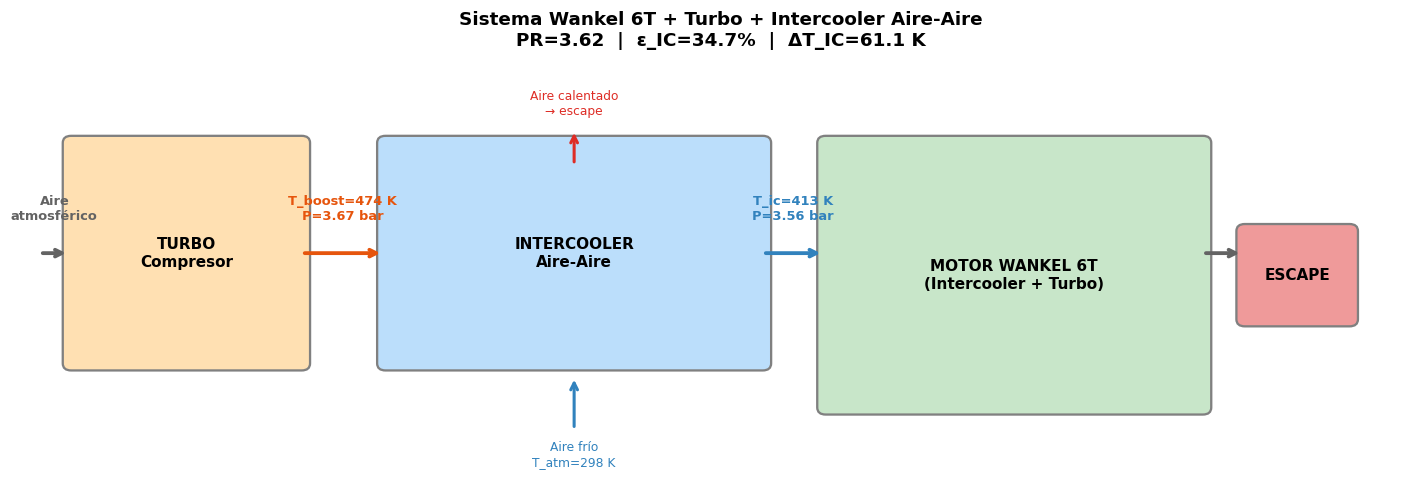

In [ ]:
fig1, ax = plt.subplots(figsize=(13, 4.5))
ax.set_xlim(0,13); ax.set_ylim(0,4.5); ax.axis('off')
comps = [(0.3,1.0,2.2,2.5,'#ffe0b2','TURBO\nCompresor'),
         (3.3,1.0,3.6,2.5,'#bbdefb','INTERCOOLER\nAire-Aire'),
         (7.5,0.5,3.6,3.0,'#c8e6c9','MOTOR WANKEL 6T\n(Intercooler + Turbo)'),
         (11.5,1.5,1.0,1.0,'#ef9a9a','ESCAPE')]
for (x,y,w,h,col,txt) in comps:
    ax.add_patch(mpatches.FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.08",
                 fc=col,ec='gray',lw=1.5))
    ax.text(x+w/2,y+h/2,txt,ha='center',va='center',fontsize=10,fontweight='bold')
arrows=[(0.0,2.25,0.28,'#636363','Aire\natmosférico'),
        (2.5,2.25,0.78,'#e6550d',f'T_boost={T_boost_nom:.0f} K\nP={P_boost_nom/1e5:.2f} bar'),
        (6.9,2.25,0.58,'#3182bd',f'T_ic={T_ic_sal:.0f} K\nP={P_ic_sal/1e5:.2f} bar'),
        (11.1,2.25,0.38,'#636363','')]
for (x,y,dx,col,lbl) in arrows:
    ax.annotate('',xy=(x+dx,y),xytext=(x,y),arrowprops=dict(arrowstyle='->',color=col,lw=2.5))
    if lbl: ax.text(x+dx/2,y+0.35,lbl,ha='center',va='bottom',fontsize=8.5,color=col,fontweight='bold')
ax.annotate('',xy=(5.1,0.85),xytext=(5.1,0.25),arrowprops=dict(arrowstyle='->',color='#3182bd',lw=2))
ax.text(5.1,0.12,f'Aire frío\nT_atm={T_atm:.0f} K',ha='center',va='top',fontsize=8,color='#3182bd')
ax.annotate('',xy=(5.1,3.65),xytext=(5.1,3.25),arrowprops=dict(arrowstyle='->',color='#de2d26',lw=2))
ax.text(5.1,3.78,'Aire calentado\n→ escape',ha='center',va='bottom',fontsize=8,color='#de2d26')
ax.set_title(f'Sistema Wankel 6T + Turbo + Intercooler Aire-Aire\n'
             f'PR={PR_nom:.2f}  |  ε_IC={eps_nom*100:.1f}%  |  ΔT_IC={DeltaT_efectivo:.1f} K',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

### Figura 2 — Números adimensionales (Re, Pr, Nu, h)

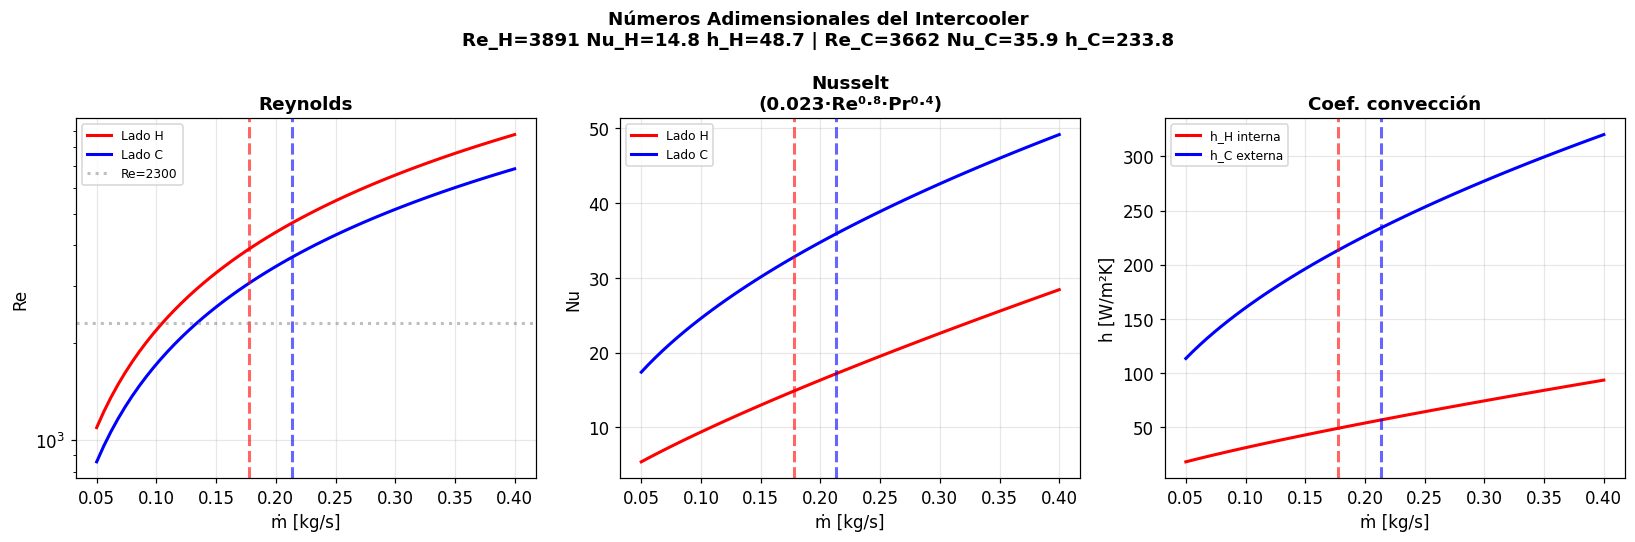

In [ ]:
m_arr = np.linspace(0.05,0.40,60)
Re_H_a=[];Nu_H_a=[];h_H_a=[];Re_C_a=[];Nu_C_a=[];h_C_a=[]
for mi in m_arr:
    vi=mi/(N_H*A_cross_H*rho_H_nom); Rei=rho_H_nom*vi*D_h_H/props_H['mu']
    Nui=0.023*Rei**0.8*Pr_H**0.4; Re_H_a.append(Rei);Nu_H_a.append(Nui);h_H_a.append(Nui*props_H['k']/D_h_H)
    vc=mi/(N_C*A_cross_C*rho_C_nom); Rec=rho_C_nom*vc*D_h_C/props_C['mu']
    Nuc=(0.664*Rec**0.5*Pr_C**(1/3) if Rec<5e5 else (0.037*Rec**0.8-871)*Pr_C**(1/3))
    Re_C_a.append(Rec);Nu_C_a.append(Nuc);h_C_a.append(Nuc*props_C['k']/D_h_C)
Re_H_a,Nu_H_a,h_H_a=map(np.array,(Re_H_a,Nu_H_a,h_H_a))
Re_C_a,Nu_C_a,h_C_a=map(np.array,(Re_C_a,Nu_C_a,h_C_a))
fig2,ax2=plt.subplots(1,3,figsize=(15,5))
ax2[0].plot(m_arr,Re_H_a,'r-',label='Lado H'); ax2[0].plot(m_arr,Re_C_a,'b-',label='Lado C')
ax2[0].axvline(m_dot_H,color='r',ls='--',alpha=.6); ax2[0].axvline(m_dot_C,color='b',ls='--',alpha=.6)
ax2[0].axhline(2300,color='gray',ls=':',alpha=.5,label='Re=2300')
ax2[0].set_xlabel('ṁ [kg/s]');ax2[0].set_ylabel('Re');ax2[0].set_title('Reynolds');ax2[0].legend(fontsize=8);ax2[0].set_yscale('log')
ax2[1].plot(m_arr,Nu_H_a,'r-',label='Lado H');ax2[1].plot(m_arr,Nu_C_a,'b-',label='Lado C')
ax2[1].axvline(m_dot_H,color='r',ls='--',alpha=.6);ax2[1].axvline(m_dot_C,color='b',ls='--',alpha=.6)
ax2[1].set_xlabel('ṁ [kg/s]');ax2[1].set_ylabel('Nu');ax2[1].set_title('Nusselt\n(0.023·Re⁰·⁸·Pr⁰·⁴)');ax2[1].legend(fontsize=8)
ax2[2].plot(m_arr,h_H_a,'r-',label='h_H interna');ax2[2].plot(m_arr,h_C_a,'b-',label='h_C externa')
ax2[2].axvline(m_dot_H,color='r',ls='--',alpha=.6);ax2[2].axvline(m_dot_C,color='b',ls='--',alpha=.6)
ax2[2].set_xlabel('ṁ [kg/s]');ax2[2].set_ylabel('h [W/m²K]');ax2[2].set_title('Coef. convección');ax2[2].legend(fontsize=8)
plt.suptitle(f'Números Adimensionales del Intercooler\n'
             f'Re_H={Re_H:.0f} Nu_H={Nu_H:.1f} h_H={h_H:.1f} | Re_C={Re_C:.0f} Nu_C={Nu_C:.1f} h_C={h_C:.1f}',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

### Figura 3 — Modelo 0D transitorio

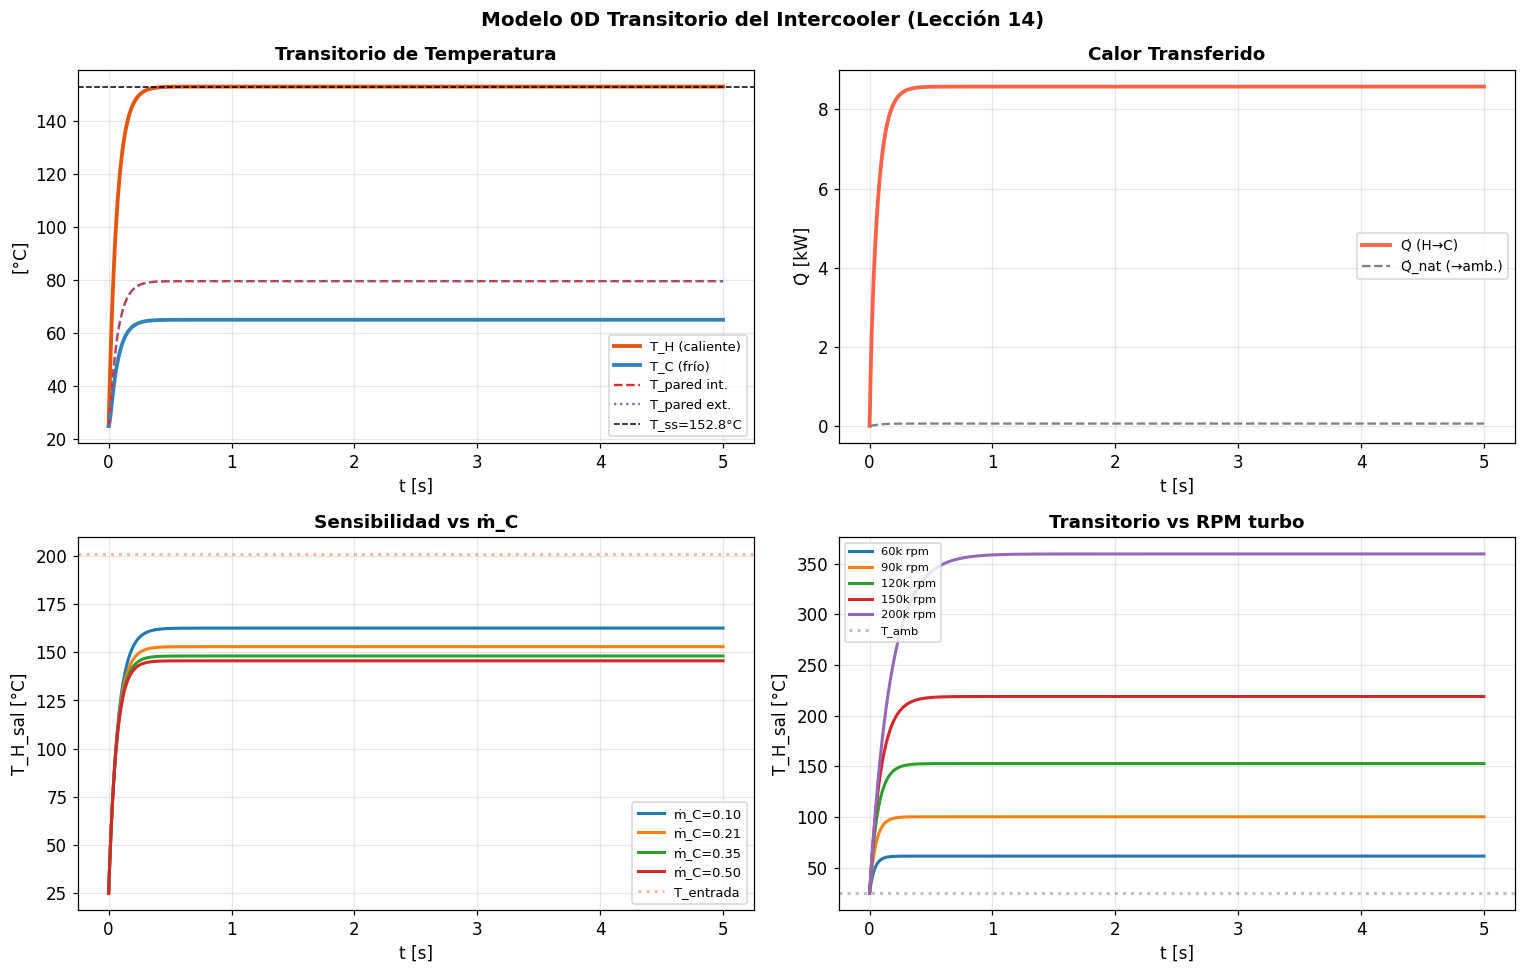

In [ ]:
fig3,ax3=plt.subplots(2,2,figsize=(14,9))
a=ax3[0,0]
a.plot(sol.t,T_H_trans-273.15,color=COLORES['turbo'],lw=2.5,label='T_H (caliente)')
a.plot(sol.t,T_C_trans-273.15,color=COLORES['ic'],lw=2.5,label='T_C (frío)')
a.plot(sol.t,T_w1_trans-273.15,color=COLORES['wall'],lw=1.5,ls='--',label='T_pared int.')
a.plot(sol.t,T_w2_trans-273.15,color='#756bb1',lw=1.5,ls=':',label='T_pared ext.')
a.axhline(T_H_ss-273.15,color='black',ls='--',lw=1,label=f'T_ss={T_H_ss-273.15:.1f}°C')
a.set_xlabel('t [s]');a.set_ylabel('[°C]');a.set_title('Transitorio de Temperatura');a.legend(fontsize=8.5)
a=ax3[0,1]
Q_nat_t=np.array([perdida_natural(T_H_trans[i])[0] for i in range(len(sol.t))])
a.plot(sol.t,Q1_trans/1000,color='tomato',lw=2.5,label='Q̇ (H→C)')
a.plot(sol.t,Q_nat_t/1000,color='gray',lw=1.5,ls='--',label='Q̇_nat (→amb.)')
a.set_xlabel('t [s]');a.set_ylabel('Q̇ [kW]');a.set_title('Calor Transferido');a.legend(fontsize=9)
a=ax3[1,0]
for mci in [0.10,0.21,0.35,0.50]:
    si=solve_ivp(lambda t,y:sistema_odes(t,y,T_boost_nom,T_atm,m_dot_H,mci,rho_H_nom,rho_C_nom,V_H,V_C,R_total),
                 (0,5),[T_atm,T_atm],t_eval=t_eval,method='RK45',rtol=1e-6,atol=1e-8)
    a.plot(si.t,si.y[0]-273.15,lw=2,label=f'ṁ_C={mci:.2f}')
a.axhline(T_boost_nom-273.15,color=COLORES['turbo'],ls=':',alpha=.4,label='T_entrada')
a.set_xlabel('t [s]');a.set_ylabel('T_H_sal [°C]');a.set_title('Sensibilidad vs ṁ_C');a.legend(fontsize=8.5)
a=ax3[1,1]
for rpm in [60000,90000,120000,150000,200000]:
    om=rpm*np.pi/30
    rc_=compresor_centrifugo(V_dot_turbo,om,r1_c,r2_c,b1_c,b2_c,beta1_deg,beta2_deg,P_atm,T_atm,eta_c,rho_atm)
    rhi=rc_['P02']/(R_air*rc_['T02'])
    si=solve_ivp(lambda t,y:sistema_odes(t,y,rc_['T02'],T_atm,rc_['m_dot'],m_dot_C,rhi,rho_C_nom,V_H,V_C,R_total),
                 (0,5),[T_atm,T_atm],t_eval=t_eval,method='RK45',rtol=1e-6,atol=1e-8)
    a.plot(si.t,si.y[0]-273.15,lw=2,label=f'{rpm//1000}k rpm')
a.axhline(T_atm-273.15,color='gray',ls=':',alpha=.5,label='T_amb')
a.set_xlabel('t [s]');a.set_ylabel('T_H_sal [°C]');a.set_title('Transitorio vs RPM turbo');a.legend(fontsize=7.5)
plt.suptitle('Modelo 0D Transitorio del Intercooler (Lección 14)',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

### Figura 4 — Efectividad ε-NTU y resistencias térmicas

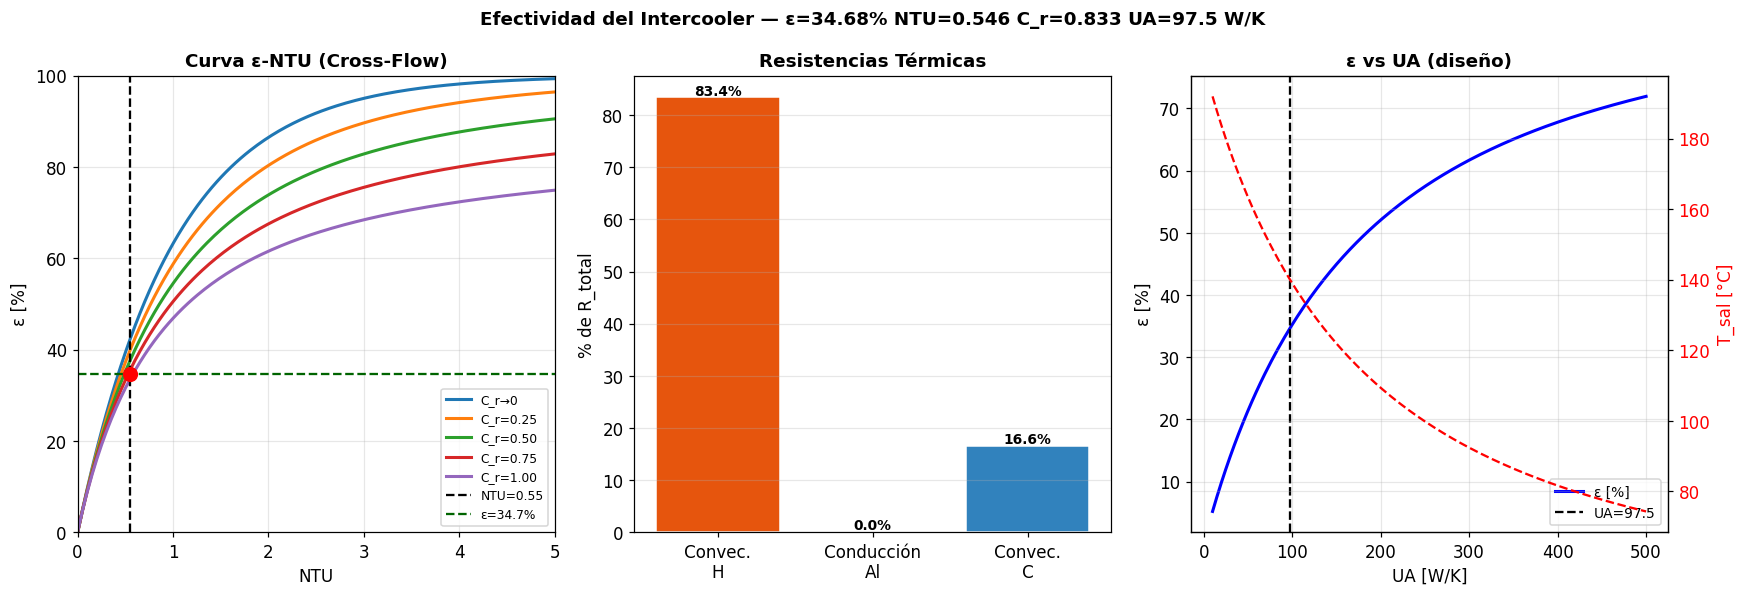

In [ ]:
fig4,ax4=plt.subplots(1,3,figsize=(16,5.5))
a=ax4[0]; ntu_x=np.linspace(0,5,200)
for cri in [0.0,0.25,0.50,0.75,1.0]:
    epi=np.array([efectividad_crossflow(n,cri) for n in ntu_x])
    a.plot(ntu_x,epi*100,lw=2,label=('C_r→0' if cri<.01 else f'C_r={cri:.2f}'))
a.axvline(NTU,color='black',ls='--',lw=1.5,label=f'NTU={NTU:.2f}')
a.axhline(eps_nom*100,color='darkgreen',ls='--',lw=1.5,label=f'ε={eps_nom*100:.1f}%')
a.scatter([NTU],[eps_nom*100],color='red',s=80,zorder=5)
a.set_xlabel('NTU');a.set_ylabel('ε [%]');a.set_title('Curva ε-NTU (Cross-Flow)');a.legend(fontsize=8);a.set_xlim(0,5);a.set_ylim(0,100)
a=ax4[1]
R_vals=[R_conv_H,R_cond,R_conv_C]; R_pct=[r/R_total*100 for r in R_vals]
names=['Convec.\nH','Conducción\nAl','Convec.\nC']; cb=[COLORES['turbo'],'#de2d26',COLORES['ic']]
bars=a.bar(names,R_pct,color=cb,edgecolor='white')
for b,p in zip(bars,R_pct): a.text(b.get_x()+b.get_width()/2,b.get_height()+0.5,f'{p:.1f}%',ha='center',fontsize=9,fontweight='bold')
a.set_ylabel('% de R_total');a.set_title('Resistencias Térmicas');a.grid(axis='x',alpha=0)
a=ax4[2]
UA_r=np.linspace(10,500,200); eps_UA=np.array([efectividad_crossflow(ua/C_min,C_r) for ua in UA_r])
Tsal=T_boost_nom-eps_UA*(T_boost_nom-T_atm)
a.plot(UA_r,eps_UA*100,'b-',lw=2,label='ε [%]'); a.axvline(UA,color='black',ls='--',lw=1.5,label=f'UA={UA:.1f}')
a.set_xlabel('UA [W/K]');a.set_ylabel('ε [%]');a.set_title('ε vs UA (diseño)')
ar=a.twinx(); ar.plot(UA_r,Tsal-273.15,'r--',lw=1.5); ar.set_ylabel('T_sal [°C]',color='red');ar.tick_params(axis='y',labelcolor='red')
a.legend(fontsize=9)
plt.suptitle(f'Efectividad del Intercooler — ε={eps_nom*100:.2f}% NTU={NTU:.3f} C_r={C_r:.3f} UA={UA:.1f} W/K',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

### Figura 5 — Temperatura y densidad de admisión vs PR

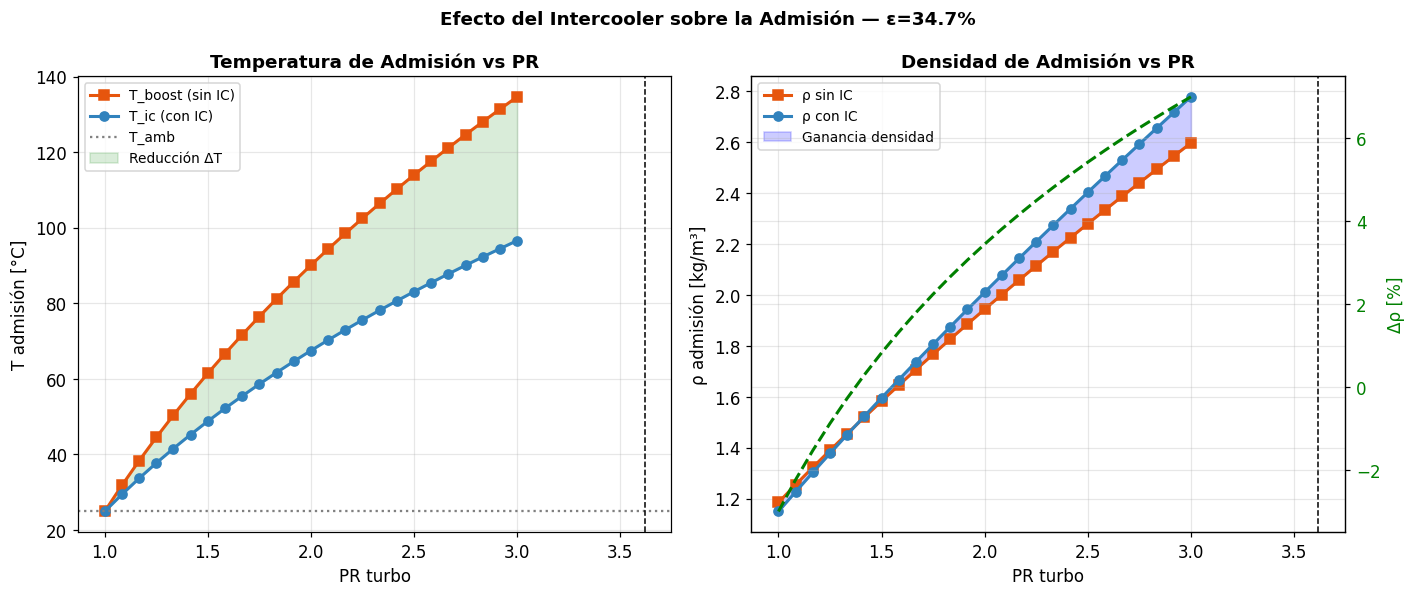

In [ ]:
fig5,ax5=plt.subplots(1,2,figsize=(13,5.5))
a=ax5[0]
a.plot(PR_range,T_boost_range-273.15,'s-',color=COLORES['turbo'],lw=2,label='T_boost (sin IC)')
a.plot(PR_range,T_ic_range-273.15,'o-',color=COLORES['ic'],lw=2,label='T_ic (con IC)')
a.axhline(T_atm-273.15,color='gray',ls=':',lw=1.5,label='T_amb')
a.fill_between(PR_range,T_ic_range-273.15,T_boost_range-273.15,alpha=.15,color='green',label='Reducción ΔT')
a.axvline(PR_nom,color='black',ls='--',lw=1)
a.set_xlabel('PR turbo');a.set_ylabel('T admisión [°C]');a.set_title('Temperatura de Admisión vs PR');a.legend(fontsize=9)
a=ax5[1]
a.plot(PR_range,rho_noIC,'s-',color=COLORES['turbo'],lw=2,label='ρ sin IC')
a.plot(PR_range,rho_IC,'o-',color=COLORES['ic'],lw=2,label='ρ con IC')
a.fill_between(PR_range,rho_noIC,rho_IC,alpha=.2,color='blue',label='Ganancia densidad')
a.axvline(PR_nom,color='black',ls='--',lw=1)
a.set_xlabel('PR turbo');a.set_ylabel('ρ admisión [kg/m³]');a.set_title('Densidad de Admisión vs PR')
ar=a.twinx(); ar.plot(PR_range,delta_rho,'g--',lw=2); ar.set_ylabel('Δρ [%]',color='green');ar.tick_params(axis='y',labelcolor='green')
a.legend(fontsize=9)
plt.suptitle(f'Efecto del Intercooler sobre la Admisión — ε={eps_nom*100:.1f}%',fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

### Figura 6 — Comparación de configuraciones (ganancia de potencia)

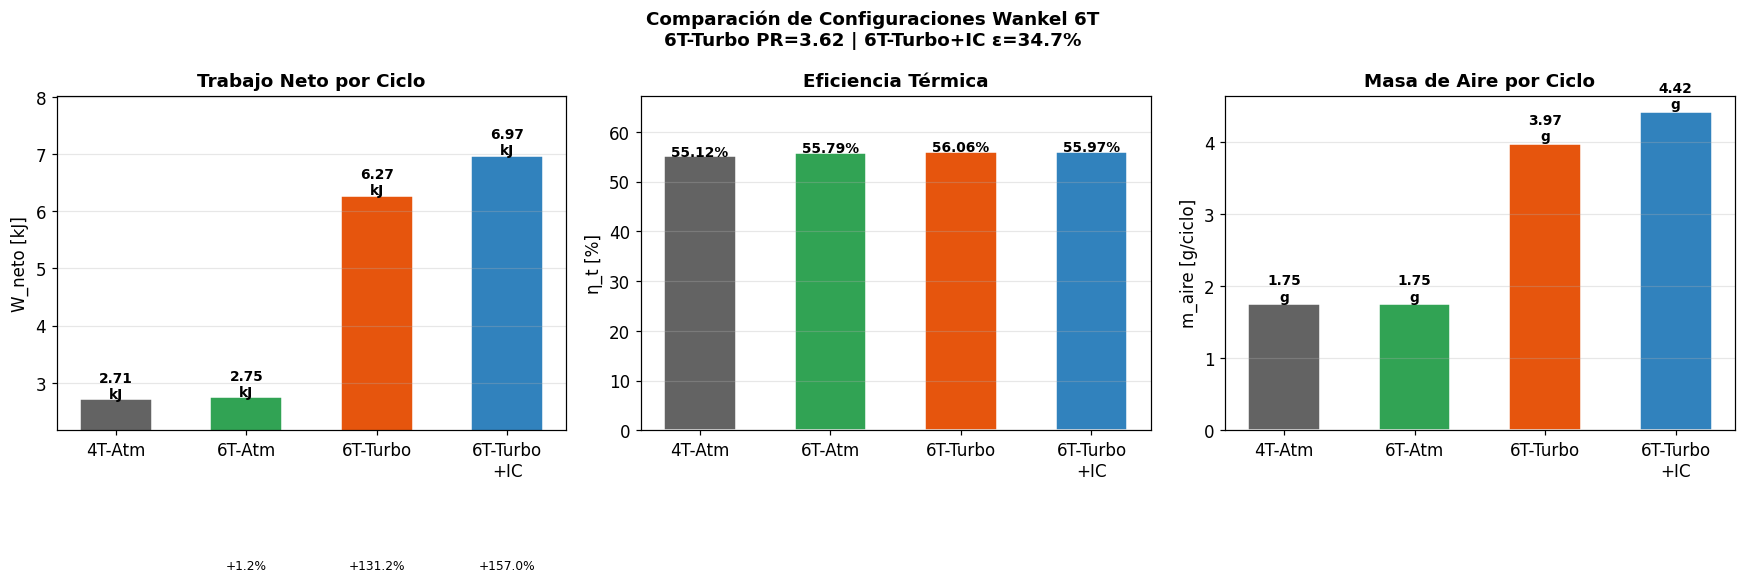

In [ ]:
labels=['4T-Atm','6T-Atm','6T-Turbo','6T-Turbo\n+IC']
W_vals=[c['W_neto'] for c in [r4T_atm,r6T_atm,r6T_turbo,r6T_ic]]
eta_vals=[c['eta_t'] for c in [r4T_atm,r6T_atm,r6T_turbo,r6T_ic]]
m_a_vals=[c['m_aire']*1e3 for c in [r4T_atm,r6T_atm,r6T_turbo,r6T_ic]]
cc=[COLORES['atm'],COLORES['6tatm'],COLORES['turbo'],COLORES['ic']]
fig6,ax6=plt.subplots(1,3,figsize=(16,6))
a=ax6[0]; bars=a.bar(labels,[w/1000 for w in W_vals],color=cc,edgecolor='white',width=.55)
for b,v in zip(bars,W_vals): a.text(b.get_x()+b.get_width()/2,b.get_height()+.02,f'{v/1000:.2f}\nkJ',ha='center',fontsize=9,fontweight='bold')
for i,(b,v) in enumerate(zip(bars[1:],W_vals[1:]),1):
    a.text(b.get_x()+b.get_width()/2,-.08,f'{(v-W_vals[0])/abs(W_vals[0])*100:+.1f}%',ha='center',va='top',fontsize=8)
a.set_ylabel('W_neto [kJ]');a.set_title('Trabajo Neto por Ciclo');a.set_ylim(min(W_vals)/1000*.8,max(W_vals)/1000*1.15);a.grid(axis='x',alpha=0)
a=ax6[1]; bars=a.bar(labels,eta_vals,color=cc,edgecolor='white',width=.55)
for b,v in zip(bars,eta_vals): a.text(b.get_x()+b.get_width()/2,b.get_height()+.1,f'{v:.2f}%',ha='center',fontsize=9,fontweight='bold')
a.set_ylabel('η_t [%]');a.set_title('Eficiencia Térmica');a.set_ylim(0,max(eta_vals)*1.2);a.grid(axis='x',alpha=0)
a=ax6[2]; bars=a.bar(labels,m_a_vals,color=cc,edgecolor='white',width=.55)
for b,v in zip(bars,m_a_vals): a.text(b.get_x()+b.get_width()/2,b.get_height()+.05,f'{v:.2f}\ng',ha='center',fontsize=9,fontweight='bold')
a.set_ylabel('m_aire [g/ciclo]');a.set_title('Masa de Aire por Ciclo');a.grid(axis='x',alpha=0)
plt.suptitle(f'Comparación de Configuraciones Wankel 6T\n'
             f'6T-Turbo PR={PR_nom:.2f} | 6T-Turbo+IC ε={eps_nom*100:.1f}%',fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

### Figura 7 — Diagramas P-V

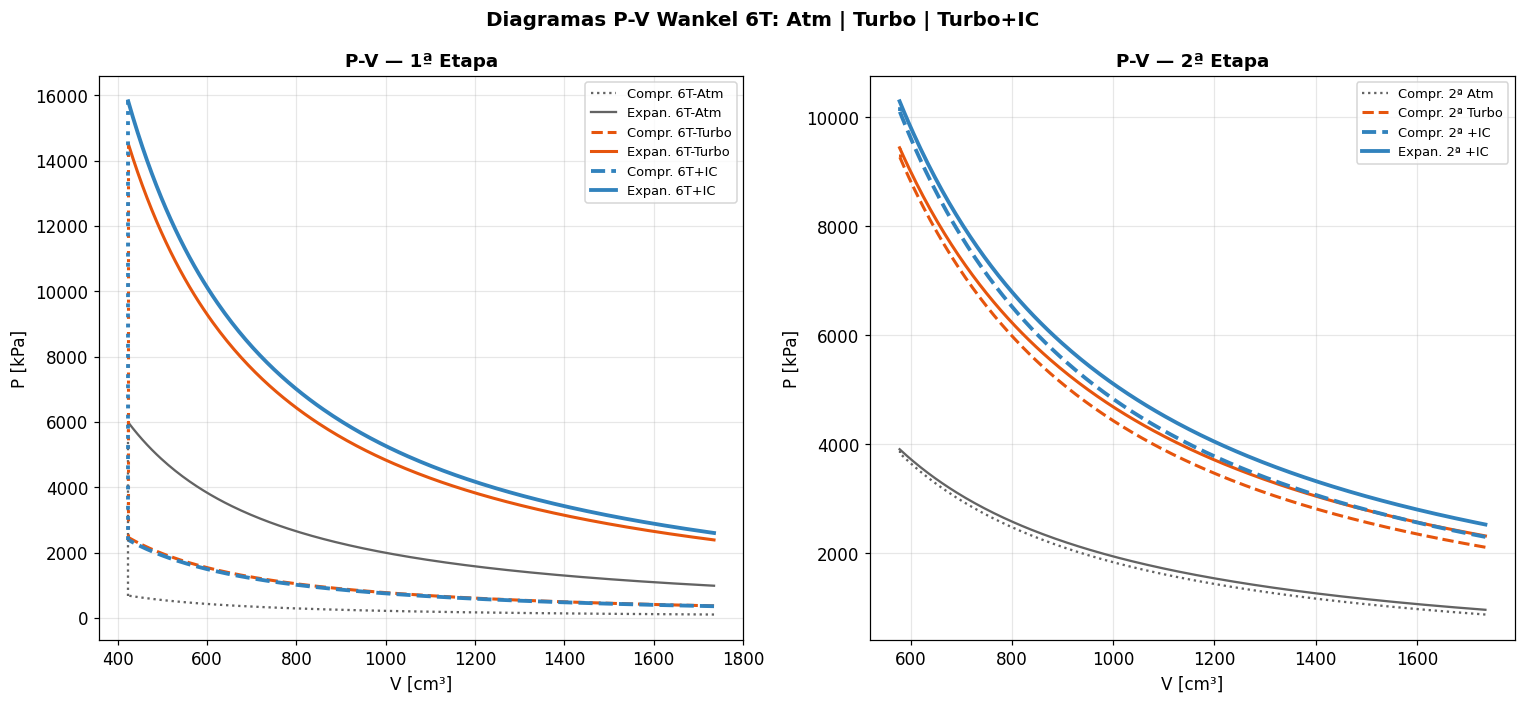

In [ ]:
def construir_pv_6T(c,V_max,rc_1,rc_2,n_comp=1.35,n_exp=1.28,N=250):
    VA=np.linspace(V_max,V_max/rc_1,N); PcA=c['P1']*(V_max/VA)**n_comp
    VeA=np.linspace(V_max/rc_1,V_max,N); PeA=c['P3']*((V_max/rc_1)/VeA)**n_exp
    VB=np.linspace(V_max,V_max/rc_2,N); PcB=c['P4m']*(V_max/VB)**n_comp
    VeB=np.linspace(V_max/rc_2,V_max,N); PeB=c['P6']*((V_max/rc_2)/VeB)**n_exp
    return VA,PcA,VeA,PeA,VB,PcB,VeB,PeB
pv_t=construir_pv_6T(r6T_turbo,V_max_6T,rc_6T_1,rc_6T_2)
pv_i=construir_pv_6T(r6T_ic,V_max_6T,rc_6T_1,rc_6T_2)
pv_a=construir_pv_6T(r6T_atm,V_max_6T,rc_6T_1,rc_6T_2)
fig7,ax7=plt.subplots(1,2,figsize=(14,6.5))
a=ax7[0]
a.plot(pv_a[0]*1e6,pv_a[1]/1e3,color=COLORES['atm'],lw=1.5,ls=':',label='Compr. 6T-Atm')
a.plot(pv_a[2]*1e6,pv_a[3]/1e3,color=COLORES['atm'],lw=1.5,label='Expan. 6T-Atm')
a.plot(pv_t[0]*1e6,pv_t[1]/1e3,color=COLORES['turbo'],lw=2,ls='--',label='Compr. 6T-Turbo')
a.plot(pv_t[2]*1e6,pv_t[3]/1e3,color=COLORES['turbo'],lw=2,label='Expan. 6T-Turbo')
a.plot(pv_i[0]*1e6,pv_i[1]/1e3,color=COLORES['ic'],lw=2.5,ls='--',label='Compr. 6T+IC')
a.plot(pv_i[2]*1e6,pv_i[3]/1e3,color=COLORES['ic'],lw=2.5,label='Expan. 6T+IC')
Vm1=V_max_6T/rc_6T_1
for rc_,col,lw in [(r6T_atm,COLORES['atm'],1.5),(r6T_turbo,COLORES['turbo'],2),(r6T_ic,COLORES['ic'],2.5)]:
    a.plot([Vm1*1e6]*2,[rc_['P2']/1e3,rc_['P3']/1e3],color=col,ls=':',lw=lw)
a.set_xlabel('V [cm³]');a.set_ylabel('P [kPa]');a.set_title('P-V — 1ª Etapa');a.legend(fontsize=8.5)
a=ax7[1]
a.plot(pv_a[4]*1e6,pv_a[5]/1e3,color=COLORES['atm'],lw=1.5,ls=':',label='Compr. 2ª Atm')
a.plot(pv_a[6]*1e6,pv_a[7]/1e3,color=COLORES['atm'],lw=1.5)
a.plot(pv_t[4]*1e6,pv_t[5]/1e3,color=COLORES['turbo'],lw=2,ls='--',label='Compr. 2ª Turbo')
a.plot(pv_t[6]*1e6,pv_t[7]/1e3,color=COLORES['turbo'],lw=2)
a.plot(pv_i[4]*1e6,pv_i[5]/1e3,color=COLORES['ic'],lw=2.5,ls='--',label='Compr. 2ª +IC')
a.plot(pv_i[6]*1e6,pv_i[7]/1e3,color=COLORES['ic'],lw=2.5,label='Expan. 2ª +IC')
Vm2=V_max_6T/rc_6T_2
for rc_,col,lw in [(r6T_atm,COLORES['atm'],1.5),(r6T_turbo,COLORES['turbo'],2),(r6T_ic,COLORES['ic'],2.5)]:
    a.plot([Vm2*1e6]*2,[rc_['P5']/1e3,rc_['P6']/1e3],color=col,ls=':',lw=lw)
a.set_xlabel('V [cm³]');a.set_ylabel('P [kPa]');a.set_title('P-V — 2ª Etapa');a.legend(fontsize=8.5)
plt.suptitle('Diagramas P-V Wankel 6T: Atm | Turbo | Turbo+IC',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

### Figura 8 — Potencia y eficiencia vs PR del turbo

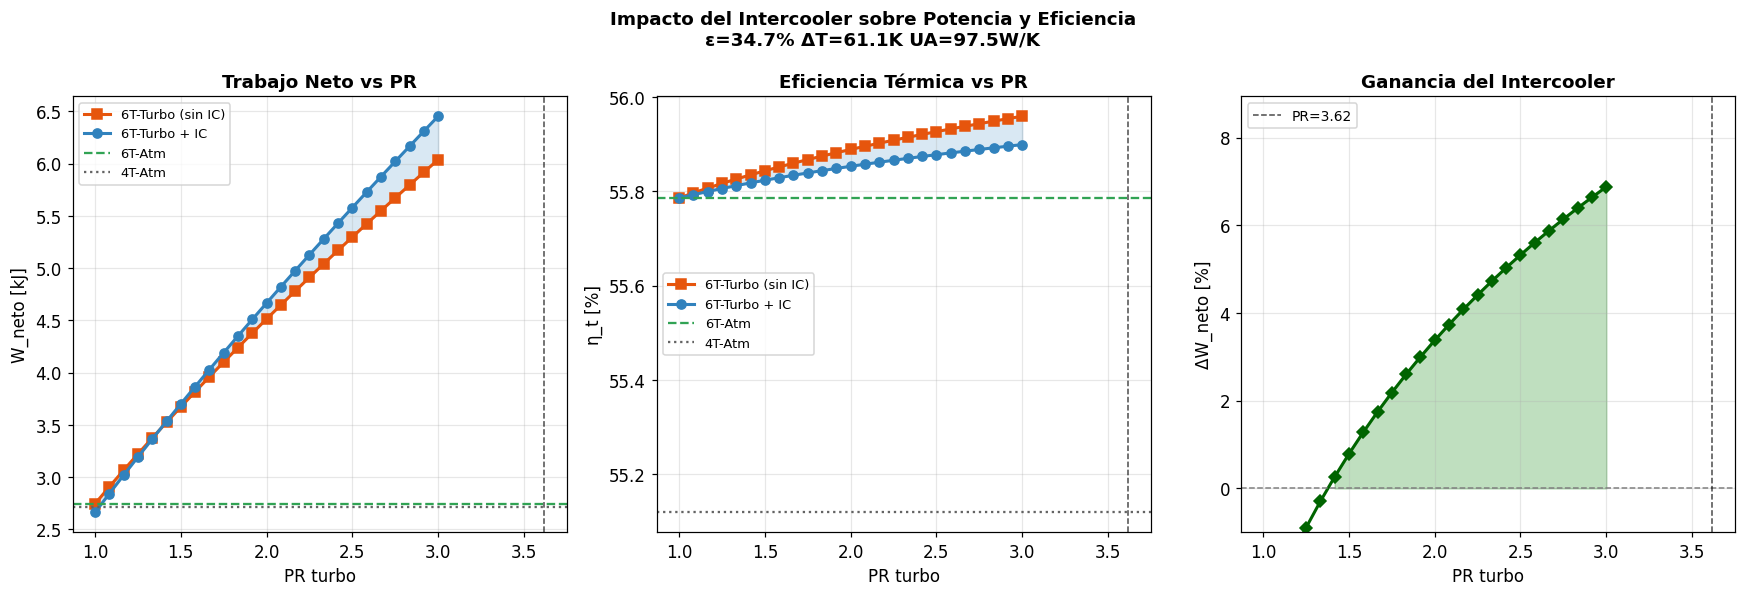

In [ ]:
fig8,ax8=plt.subplots(1,3,figsize=(16,5.5))
a=ax8[0]
a.plot(PR_range,W_6T_noIC/1000,'s-',color=COLORES['turbo'],lw=2,label='6T-Turbo (sin IC)')
a.plot(PR_range,W_6T_IC/1000,'o-',color=COLORES['ic'],lw=2,label='6T-Turbo + IC')
a.axhline(r6T_atm['W_neto']/1000,color=COLORES['6tatm'],ls='--',lw=1.5,label='6T-Atm')
a.axhline(r4T_atm['W_neto']/1000,color=COLORES['atm'],ls=':',lw=1.5,label='4T-Atm')
a.fill_between(PR_range,W_6T_noIC/1000,W_6T_IC/1000,alpha=.18,color=COLORES['ic'])
a.axvline(PR_nom,color='black',ls='--',lw=1,alpha=.7)
a.set_xlabel('PR turbo');a.set_ylabel('W_neto [kJ]');a.set_title('Trabajo Neto vs PR');a.legend(fontsize=8.5)
a=ax8[1]
a.plot(PR_range,eta_6T_noIC,'s-',color=COLORES['turbo'],lw=2,label='6T-Turbo (sin IC)')
a.plot(PR_range,eta_6T_IC,'o-',color=COLORES['ic'],lw=2,label='6T-Turbo + IC')
a.axhline(r6T_atm['eta_t'],color=COLORES['6tatm'],ls='--',lw=1.5,label='6T-Atm')
a.axhline(r4T_atm['eta_t'],color=COLORES['atm'],ls=':',lw=1.5,label='4T-Atm')
a.fill_between(PR_range,eta_6T_noIC,eta_6T_IC,alpha=.18,color=COLORES['ic'])
a.axvline(PR_nom,color='black',ls='--',lw=1,alpha=.7)
a.set_xlabel('PR turbo');a.set_ylabel('η_t [%]');a.set_title('Eficiencia Térmica vs PR');a.legend(fontsize=8.5)
a=ax8[2]
a.plot(PR_range,dW_IC_arr,'D-',color='darkgreen',lw=2)
a.fill_between(PR_range,0,dW_IC_arr,alpha=.25,color='green',where=(dW_IC_arr>0))
a.axhline(0,color='gray',ls='--',lw=1); a.axvline(PR_nom,color='black',ls='--',lw=1,alpha=.7,label=f'PR={PR_nom:.2f}')
a.set_xlabel('PR turbo');a.set_ylabel('ΔW_neto [%]');a.set_title('Ganancia del Intercooler');a.legend(fontsize=9);a.set_ylim(-1,max(dW_IC_arr)*1.3)
plt.suptitle(f'Impacto del Intercooler sobre Potencia y Eficiencia\nε={eps_nom*100:.1f}% ΔT={DeltaT_efectivo:.1f}K UA={UA:.1f}W/K',
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

## 12. Conclusiones

El intercooler aire-aire, modelado en régimen transitorio 0D, demuestra que:

- **Enfría el aire de admisión** desde la temperatura de salida del turbo hasta una temperatura mucho más cercana a la ambiente, con una efectividad $\varepsilon$ que depende del NTU del intercambiador.
- **Aumenta la densidad del aire admitido** al motor, lo que permite atrapar más masa de aire+combustible por ciclo.
- **Incrementa el trabajo neto del Wankel 6T** respecto a la configuración turbo sin intercooler, sin penalizar significativamente la eficiencia térmica (la pequeña caída de presión del 3% es ampliamente compensada por el aumento de densidad).
- La ganancia del intercooler **crece con la relación de compresión del turbo (PR)**, porque a mayor PR el aire sale más caliente del compresor y, por tanto, hay más margen para enfriarlo.

### Limitaciones y trabajo futuro

1. El modelo asume propiedades del aire constantes evaluadas a la temperatura de película.
2. La caída de presión del intercooler se estima en 3% (típico automotriz); podría modelarse con el factor de fricción de Darcy.
3. No se incluye la aleta secundaria del lado frío.
4. Validar la efectividad con datos experimentales pero con intercoolers comerciales de tamaño similar.

---
*LUIS ALEJANDRO GARZÓN & MARCO RIVADENEIRA*